In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
import shap
from imblearn.over_sampling import SMOTE


In [2]:
df = pd.read_csv('/content/drive/MyDrive/nova_pay_combined.csv')
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [3]:
df.shape

(11400, 26)

In [4]:
df.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='object')

DATA DICTIONARY FOR NOVA PAY TRANSACTION DATASET

This is an explanation of each field in the dataset.





| Column Name | Data Type | Description | Example |
|-------------|-----------|-------------|---------|
| transaction_id | String | Unique identifier for each transaction | TXN102345 |
| customer_id | String | Unique identifier for the customer initiating the transaction | CUST5678 |
| timestamp | Datetime | Date and time when the transaction occurred | 2025-11-01 10:23:45 |
| home_country | String | Country where the customer account is registered | UK |
| source_currency | String | Currency used by the sender | GBP |
| dest_currency | String | Currency received by the recipient | USD |
| channel | Categorical | Platform used for the transaction (mobile, web, API) | mobile |
| amount_src | Float | Transaction amount in the source currency | 500.00 |
| amount_usd | Float | Transaction amount converted to USD | 620.50 |
| fee | Float | Transaction fee charged by the platform | 5.50 |
| exchange_rate_src_to_dest | Float | Exchange rate applied from source to destination currency | 1.24 |
| device_id | String | Unique identifier for the device used | DEV98765 |
| new_device | Binary | Indicates if the device is new (1 = Yes, 0 = No) | 1 |
| ip_address | String | IP address used for the transaction | 192.168.0.1 |
| ip_country | String | Country detected from the IP address | Germany |
| location_mismatch | Binary | Indicates if IP country differs from home country | 1 |
| ip_risk_score | Float | Risk score assigned to the IP address | 0.72 |
| kyc_tier | Integer | Customer KYC verification level | 2 |
| account_age_days | Integer | Number of days since account creation | 365 |
| device_trust_score | Float | Trust score assigned to the device | 0.85 |
| chargeback_history_count | Integer | Number of previous chargebacks | 1 |
| risk_score_internal | Float | Internal fraud risk score | 0.67 |
| txn_velocity_1h | Integer | Number of transactions in the past 1 hour | 3 |
| txn_velocity_24h | Integer | Number of transactions in the past 24 hours | 12 |
| corridor_risk | Float | Risk score of the country transaction corridor | 0.55 |
| is_fraud | Binary | Fraud label (1 = Fraud, 0 = Legitimate) | 0 |

In [5]:
#checking for missing data
df.isnull().sum()

,0
transaction_id,0
customer_id,0
timestamp,29
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,305
fee,295


Checking the missing values in each variable, we can confirm that:

- timestamp has 29 missing values

- amount_usd has 305 missing values

- fee has 295 missing values

- ip_address has 305 missing values

- ip_country has 301 missing values

- kyc_tier has 300 missing values

- device_trust_score has 295 missing values

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  object 
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  obj

From the above inspection we can see that timestamp is stored as a wrong data type, an object data type instead of datetime format. Also amount_src variable is also stored as object data type rather than float or integer.

In [7]:
df['timestamp'].value_counts(dropna=False).head(20)

,count
timestamp,
NaN,29
0000-00-00T00:00:00Z,21
2025/13/40 25:61:00,11
2024-12-08 20:25:58.468549+00:00,2
2023-07-21 03:56:58.468549+00:00,2
2024-01-22 00:24:24.468549+00:00,2
2024-12-14 08:44:42.468549+00:00,2
2024-10-14 15:56:36.468549+00:00,2
2024-08-05 08:46:02.468549+00:00,2


From our value_counts we can see that 32 datas has inavlid timestamp which will lead to nan values when the data type is converted

In [8]:
df['amount_src'].dtype

dtype('O')

In [9]:
df['amount_src'].unique()[:20]

array(['278.19', '208.51', '160.33', '59.41', '200.96', '526.9', '149.24',
       '276.51', '99.52', '302.55', '187.84', '9998.43', '171.86',
       '322.24', '87.81', '9991.85', '309.39', '260.49', '87.5', '254.76'],
      dtype=object)

In [10]:
df['amount_src'].value_counts(dropna=False).head(20)

,count
amount_src,
100.0,15
102.29,5
144.29,4
261.23,4
102.37,4
82.25,4
115.29,4
119.15,4
94.34,4


In [11]:
#checking for label imbalance
df['is_fraud'].value_counts(normalize=True).reset_index()

,is_fraud,proportion
0,0,0.912544
1,1,0.087456


The is_fraud variable which happens to be our target variable is unevenly distributed. About 91% of the target variable confirms transaction is legitimate while 9% confirms that transaction is_fraud.

**SUMMARY/OBSERVATIONS**

- The composition of the dataset is 11400 rows and 26 columns

- All fieldnames follows the standard variable naming conventions

- An initial inspection of the dataset revealed inconsistencies in the data types of certain variables. Specifically, the timestamp variable is currently stored as an object data type instead of the appropriate datetime format, which is necessary for accurate time-based analysis. Similarly, the amount_src variable is also stored as an object data type, whereas it should ideally be represented as a numeric format (integer or float) to allow for proper numerical computations and analysis. These inconsistencies will need to be corrected during the data preprocessing stage.

- An assessment of missing values across the dataset revealed that several variables contain incomplete records. Specifically, the timestamp variable contains 29 missing values, while amount_usd and ip_address each contain 305 missing values. Additionally, the fee and device_trust_score variables both have 295 missing values, ip_country has 301 missing values, and kyc_tier contains 300 missing values. These missing values will require appropriate data cleaning and preprocessing to ensure the reliability and accuracy of subsequent analysis and modeling.

- The target variable is_fraud is highly imbalanced, with approximately 91% of transactions classified as legitimate and only 9% identified as fraudulent. This imbalance introduces a risk of model bias toward the majority class, where machine learning algorithms may prioritize predicting legitimate transactions while failing to detect fraudulent ones. As a result, relying solely on accuracy could produce misleading results. To mitigate this issue, techniques such as resampling methods and appropriate evaluation metrics should be used to ensure the model effectively identifies fraudulent transactions.

DATA CLEANING AND PREPARATION

In [12]:
#converting data types of timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'],errors='coerce')
#converting data type of income_usd to float
df['amount_src'] = pd.to_numeric(df['amount_src'],errors='coerce')


In [13]:
#checking the dataset again to confirm the data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11400 non-null  object             
 1   customer_id                11400 non-null  object             
 2   timestamp                  11339 non-null  datetime64[ns, UTC]
 3   home_country               11400 non-null  object             
 4   source_currency            11400 non-null  object             
 5   dest_currency              11400 non-null  object             
 6   channel                    11400 non-null  object             
 7   amount_src                 11396 non-null  float64            
 8   amount_usd                 11095 non-null  float64            
 9   fee                        11105 non-null  float64            
 10  exchange_rate_src_to_dest  11400 non-null  float64            
 11  de

During data preprocessing, the timestamp and amount_src variables were converted to appropriate data types using pd.to_datetime() and pd.to_numeric() with the errors='coerce' argument. This process revealed additional invalid entries that could not be parsed correctly, resulting in an increase in missing values. Specifically, the number of missing values in timestamp increased from 29 to 61, while amount_src increased from 0 to 4. These additional missing values indicate the presence of improperly formatted or corrupted records, which were subsequently handled during the data cleaning stage.

In [14]:
# Rechecking for missing data
df.isnull().sum()

,0
transaction_id,0
customer_id,0
timestamp,61
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,4
amount_usd,305
fee,295


VARIABLES WITH MISSING VALUES THAT NEEDS IMPUTATION

- amount_usd: has 305 missing values. this will be filled by multiplying the amount_src by the exchange rate of the currency

- fee: has 295 missing values which will be filled by the median of channel variable if channel exists while other remaining fee missing values will be filled using the overall median.

- ip_country: has 301 missing values which will be filled by the corresponding home_country.

- kyc_tier: has 300 missing values which will be filled with the most frequent kyc_tier(mode).

- device_trust_score: has 295 missing values. This will be filled by the median of the group from grouping device_trust_score by kyc_tier and new_device variable or by the overall median of device_trust_score.

The timestamp variable which has 61 missing values and amount_src with 4 missing values will be dropped using the dropna method because the number of missing values in both variables is very small compared to the values we have on our dataset. The ip_address variable has missing values of 305 cannot be filled with any value as each ip_address is a unique number so it will be dropped using the dropna method.

In [15]:
#calculating exchange rates per currency
exchange_rates = df[df['amount_usd'].notna()].groupby('source_currency').apply(
    lambda x: (x['amount_usd'] / x['amount_src']).mean()
).to_dict()
exchange_rates

/tmp/ipykernel_6620/2187916205.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  exchange_rates = df[df['amount_usd'].notna()].groupby('source_currency').apply(


{'CAD': 0.7216095926871465,
 'GBP': 1.223441221648679,
 'USD': 0.9838730321259439}

In [16]:
#filling the missing values of the amount_usd
df['amount_usd']=df.apply(
    lambda row: row['amount_usd'] if pd.notna(row['amount_usd']) else row['amount_src'] * exchange_rates.get(row['source_currency'],1),
    axis=1
)

In [17]:
# filling the missing values of the fee variable
if 'fee' in df.columns:
  if 'channel' in df.columns:
    df['fee'] = df.groupby('channel')['fee'].transform(lambda y: y.fillna(y.median()))
  df['fee'] = df['fee'].fillna(df['fee'].median())

In [18]:
# filling the missing values of ip_country variable
if {'ip_country', 'home_country'}.issubset(df.columns):
  df['ip_country'] = df['ip_country'].fillna(df['home_country'])

In [19]:
# filling the missing values of kyc_tier variable
if 'kyc_tier' in df.columns:
  df['kyc_tier'] = df['kyc_tier'].fillna(df['kyc_tier'].mode()[0])

In [20]:
# filling the missing values of device_trust_score variable
if 'device_trust_score' in df.columns:
  if{'new_device', 'kyc_tier'}.issubset(df.columns):
    df['device_trust_score']=df.groupby(['new_device','kyc_tier'])['device_trust_score'].transform(lambda x: x.fillna(x.median()))
  df['device_trust_score']=df['device_trust_score'].fillna(df['device_trust_score'].median())

In [21]:
# dropping the timestamp, amount_src and ip_address missing values
df.dropna(subset=['timestamp', 'amount_src', 'ip_address'], inplace=True)


In [22]:
# rechecking for missing values
df.isnull().sum()

,0
transaction_id,0
customer_id,0
timestamp,0
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,0
fee,0


Now that all missing values have been sorted out we need to do a sanity check i.e check for inconsistency in our dataset.

In [23]:
# checking overall view of each variables using .describe method
df.describe(include='all')

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11030,11030,11030,11030,11030,11030,11030,11030.000000,11030.000000,11030.000000,...,11030.000000,11030,11030.000000,11030.000000,11030.000000,11030.000000,11030.000000,11030.000000,11030.000000,11030.000000
unique,10836,1314,NaN,7,3,9,12,NaN,NaN,NaN,...,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,7e762adf-98c5-48e5-900a-b6afee5ade30,402cccc9-28de-45b3-9af7-cc5302aa1f93,NaN,US,USD,NGN,mobile,NaN,NaN,NaN,...,NaN,standard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1458,NaN,7684,7770,1426,6134,NaN,NaN,NaN,...,NaN,7883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2024-05-03 10:31:41.290405376+00:00,NaN,NaN,NaN,NaN,437.800284,448.664391,98.222628,...,0.397463,NaN,393.040435,0.654513,0.050045,0.268070,0.470263,0.740073,0.045573,0.089483
min,NaN,NaN,2022-10-03 18:40:59.468549+00:00,NaN,NaN,NaN,NaN,-9997.160000,7.230000,-1.000000,...,0.004000,NaN,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,2023-08-15 02:53:40.468549120+00:00,NaN,NaN,NaN,NaN,90.867500,92.545000,2.390000,...,0.209000,NaN,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,2024-05-09 01:16:28.968549120+00:00,NaN,NaN,NaN,NaN,159.080000,163.590000,3.510000,...,0.325000,NaN,286.500000,0.658000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,2025-01-29 07:26:17.047345408+00:00,NaN,NaN,NaN,NaN,294.940000,302.137500,5.550000,...,0.488000,NaN,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,NaN,NaN,2025-12-16 00:13:41.468549+00:00,NaN,NaN,NaN,NaN,11942.890000,12497.900000,9999.990000,...,1.200000,NaN,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


In [24]:
# checking individual columns
for col in df.columns:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in transaction_id:
['fee8542d-8ee6-4b0d-9671-c294dd08ed26'
 'bfdb9fc1-27fe-4a85-b043-4d813d679259'
 'fc855034-3ea5-4993-9afa-b511d93fe5e8' ...
 '6a51f0e8-f5d1-4fe6-91a0-655fccd79fa5'
 '4aad7389-2b62-4885-a23e-aa3ecd5cfaf9'
 'fdffeb16-192a-4483-9b1e-9928e23269c2']

Unique values in customer_id:
['402cccc9-28de-45b3-9af7-cc5302aa1f93'
 '67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad'
 '6d0d9b27-fa26-45f8-93b1-2df29d182d9c' ...
 '2003e2a1-f3b1-4e2e-8d0e-488cfacf68ca'
 '8b1cf558-4ed7-48ee-b330-75db6efd4840'
 'b69010dc-ab0a-4fd2-a79e-65e4c6efbcd9']

Unique values in timestamp:
<DatetimeArray>
['2022-10-03 18:40:59.468549+00:00', '2022-10-03 20:39:38.468549+00:00',
 '2022-10-03 23:02:43.468549+00:00', '2022-10-04 01:08:53.468549+00:00',
 '2022-10-04 09:35:03.468549+00:00', '2022-10-04 12:09:59.468549+00:00',
 '2022-10-04 12:37:41.468549+00:00', '2022-10-04 16:27:44.468549+00:00',
 '2022-10-04 21:00:36.468549+00:00', '2022-10-04 21:20:42.468549+00:00',
 ...
 '2025-11-24 13:42:17.573611+0

STEPS TO TAKE TO DO THE SANITY CHECK

- Check for invalid numbers i.e negative numbers for variables that contains age, monetary values, velocity etc

- Check if transaction timestamp appear in the future

- Check that values falls between range

- Inspect for inconsistency among variable values in the dataset

In [25]:
# Checking negative values in numeric columns
negative_counts = {
    'amount_src': (df['amount_src'] < 0).sum(),
    'amount_usd': (df['amount_usd'] < 0).sum(),
    'fee': (df['fee'] < 0).sum(),
    'device_trust_score': (df['device_trust_score'] < 0).sum(),
    'txn_velocity_1h': (df['txn_velocity_1h'] < 0).sum(),
    'txn_velocity_24h': (df['txn_velocity_24h'] < 0).sum(),
    'risk_score_internal': (df['risk_score_internal'] < 0).sum(),
}
negative_counts

{'amount_src': np.int64(100),
 'amount_usd': np.int64(0),
 'fee': np.int64(90),
 'device_trust_score': np.int64(190),
 'txn_velocity_1h': np.int64(190),
 'txn_velocity_24h': np.int64(0),
 'risk_score_internal': np.int64(0)}

In [26]:
df = df.drop(df[
    (df['amount_src'] < 0) |
    (df['fee'] < 0) |
    (df['device_trust_score'] < 0) |
    (df['txn_velocity_1h'] < 0)].index)

In [27]:
# Rechecking for negative numbers again
negative_counts = {
    'amount_src': (df['amount_src'] < 0).sum(),
    'amount_usd': (df['amount_usd'] < 0).sum(),
    'fee': (df['fee'] < 0).sum(),
    'device_trust_score': (df['device_trust_score'] < 0).sum(),
    'txn_velocity_1h': (df['txn_velocity_1h'] < 0).sum(),
    'txn_velocity_24h': (df['txn_velocity_24h'] < 0).sum(),
    'risk_score_internal': (df['risk_score_internal'] < 0).sum(),
}
negative_counts

{'amount_src': np.int64(0),
 'amount_usd': np.int64(0),
 'fee': np.int64(0),
 'device_trust_score': np.int64(0),
 'txn_velocity_1h': np.int64(0),
 'txn_velocity_24h': np.int64(0),
 'risk_score_internal': np.int64(0)}

In [28]:
# checking for futuristic timestamp
df[df['timestamp'] > pd.Timestamp.utcnow()]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud


In [29]:
# checking for location mismatch
df['location_mismatch'].value_counts().reset_index()

,location_mismatch,count
0,False,9047
1,True,1793


The above values from the value counts of location_mismatch variable is expected as the project has to do with fraudulent transaction

The channel, source_currency, dest_currency and kyc_tier has inconsistent values in the dataset.

In [30]:
# reviewing the channel variable
df['channel'].unique()

array(['ATM', 'web', 'mobile', 'WEB', ' web  ', 'MOBILE', 'unknown',
       'mobille', ' mobile  ', 'weeb', 'ATm', ' ATM  '], dtype=object)

In [31]:
#formatting the channel variable
df['channel'] = df['channel'].str.lower().str.strip()
df['channel'].unique()

array(['atm', 'web', 'mobile', 'unknown', 'mobille', 'weeb'], dtype=object)

In [32]:
df['channel'] = df['channel'].replace({
    'weeb':'web',
    'mobille':'mobile',
})

In [33]:
df['channel'] = df['channel'].replace({'unknown':np.nan})
df['channel'].unique()

array(['atm', 'web', 'mobile', nan], dtype=object)

In [34]:
# reviewing the source currency variable
df['source_currency'].unique()

array(['USD', 'CAD', 'GBP'], dtype=object)

In [35]:
# reviewing the destination currency variable
df['dest_currency'].unique()

array(['CAD', 'MXN', 'CNY', 'EUR', 'INR', 'GBP', 'PHP', 'NGN', 'USD'],
      dtype=object)

In [36]:
# reviewing the kyc_tier variable
df['kyc_tier'].unique()

array(['standard', 'enhanced', 'low', ' standard  ', 'standrd',
       ' enhanced  ', 'STANDARD', 'unknown', 'enhancd', ' low  ',
       'ENHANCED', 'LOW'], dtype=object)

In [37]:
#formatting the channel variable
df['kyc_tier'] = df['kyc_tier'].str.lower().str.strip()
df['kyc_tier'].unique()

array(['standard', 'enhanced', 'low', 'standrd', 'unknown', 'enhancd'],
      dtype=object)

In [38]:
df['kyc_tier'] = df['kyc_tier'].replace({
    'standrd':'standard',
    'enhancd':'enhanced',
    'unknown': np.nan
})
df['kyc_tier'].unique()

array(['standard', 'enhanced', 'low', nan], dtype=object)

In [39]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
timestamp,0
home_country,0
source_currency,0
dest_currency,0
channel,36
amount_src,0
amount_usd,0
fee,0


After the formatting, we got a few missing values in the channel and kyc_tier variable. These variables will be removed using the dropna method.

In [40]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10780 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             10780 non-null  object             
 1   customer_id                10780 non-null  object             
 2   timestamp                  10780 non-null  datetime64[ns, UTC]
 3   home_country               10780 non-null  object             
 4   source_currency            10780 non-null  object             
 5   dest_currency              10780 non-null  object             
 6   channel                    10780 non-null  object             
 7   amount_src                 10780 non-null  float64            
 8   amount_usd                 10780 non-null  float64            
 9   fee                        10780 non-null  float64            
 10  exchange_rate_src_to_dest  10780 non-null  float64            
 11  device_

In [41]:
# reviewing the home_country variable
df['home_country'].unique()

array(['US', 'CA', 'UK', ' UK  ', ' US  ', 'unknown', ' CA  '],
      dtype=object)

In [42]:
#formatting the home_country variable
df['home_country'] = df['home_country'].str.lower().str.strip()
df['home_country'].unique()

array(['us', 'ca', 'uk', 'unknown'], dtype=object)

In [43]:
# reviewing the ip_country variable
df['ip_country'].unique()

array(['US', 'CA', 'UK', ' US  ', 'unknown', ' CA  ', ' UK  '],
      dtype=object)

In [44]:
#formatting the ip_country variable
df['ip_country'] = df['ip_country'].str.lower().str.strip()
df['ip_country'].unique()

array(['us', 'ca', 'uk', 'unknown'], dtype=object)

From the result of our info method, all missing values, inconsistency and errors has been fixed. String values correctly formatted and data types correctly converted.

EXPLORATORY DATA ANALYSIS

<Axes: xlabel='is_fraud'>

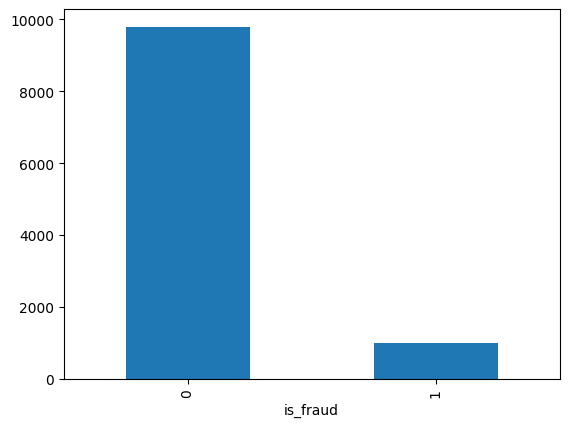

In [45]:
# checking for class imbalance of the target variable 'is_fraud'
df['is_fraud'].value_counts().plot(kind='bar')

<Axes: xlabel='channel'>

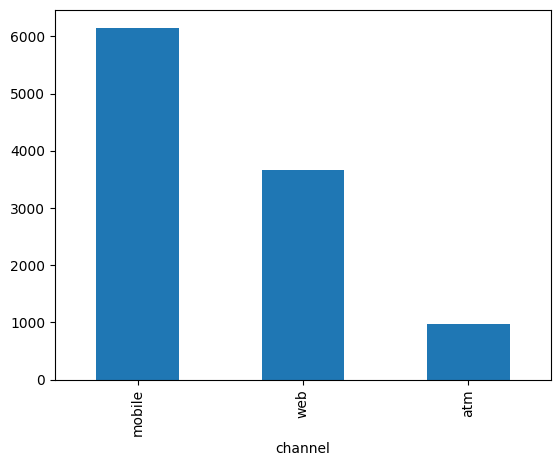

In [46]:
# channel distribution
df['channel'].value_counts().plot(kind='bar')

<Axes: xlabel='location_mismatch'>

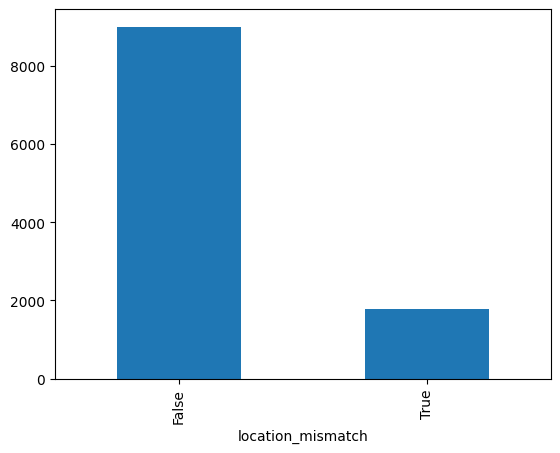

In [47]:
df['location_mismatch'].value_counts().plot(kind='bar')

<Axes: xlabel='ip_country'>

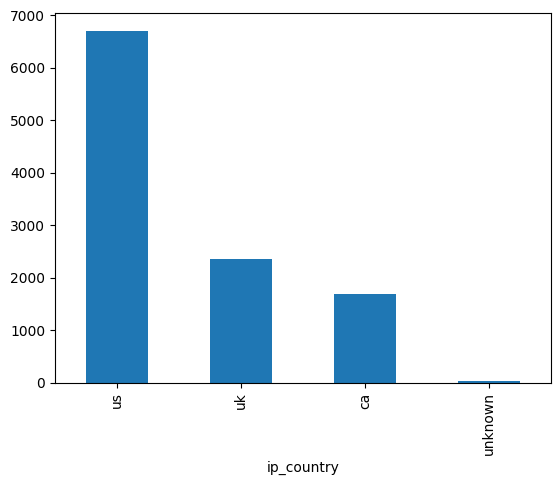

In [48]:
#counts of ip_country
df['ip_country'].value_counts().plot(kind='bar')

<Axes: xlabel='kyc_tier'>

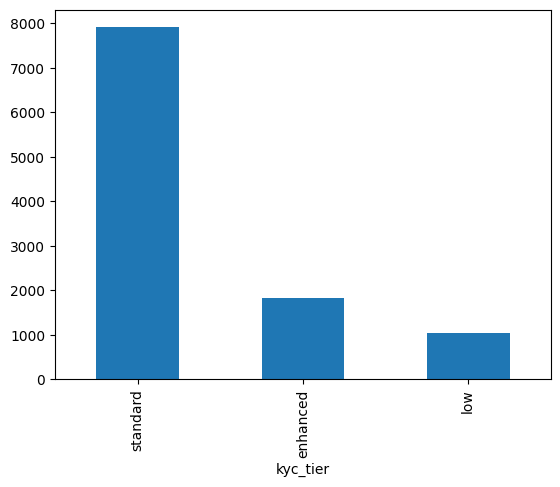

In [49]:
# counts of kyc_tier
df['kyc_tier'].value_counts().plot(kind='bar')

<Axes: xlabel='new_device'>

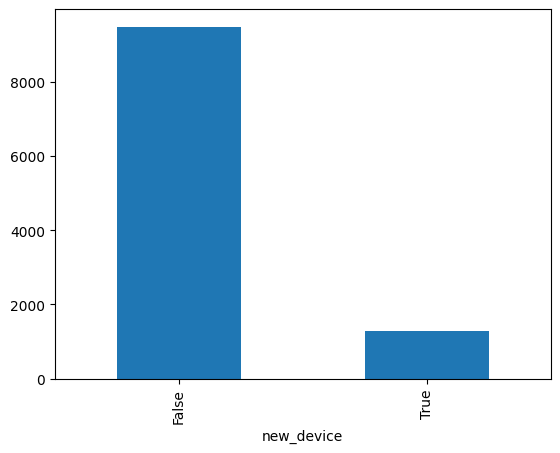

In [50]:
# Counts of new_device
df['new_device'].value_counts().plot(kind='bar')

<Axes: xlabel='source_currency'>

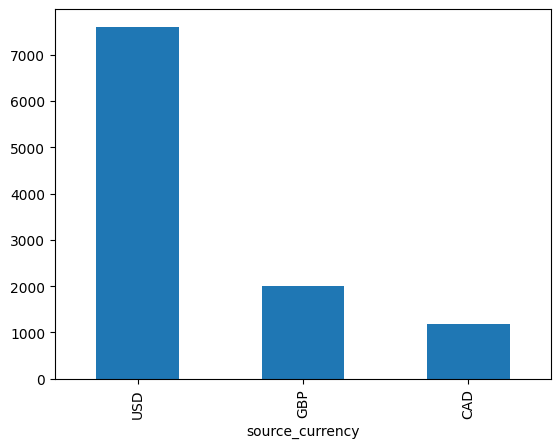

In [51]:
# counts of source_country
df['source_currency'].value_counts().plot(kind='bar')

<Axes: xlabel='dest_currency'>

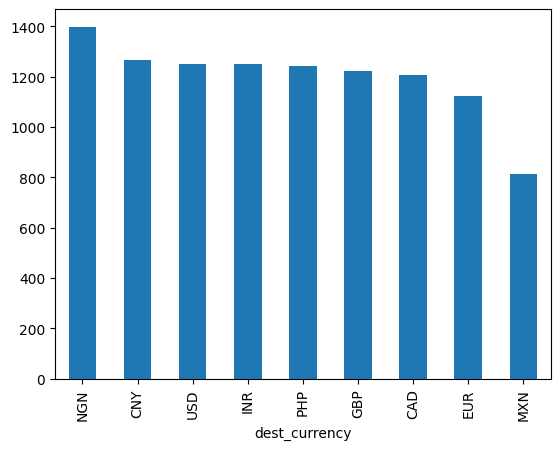

In [52]:
# counts of dest_currency
df['dest_currency'].value_counts().plot(kind='bar')

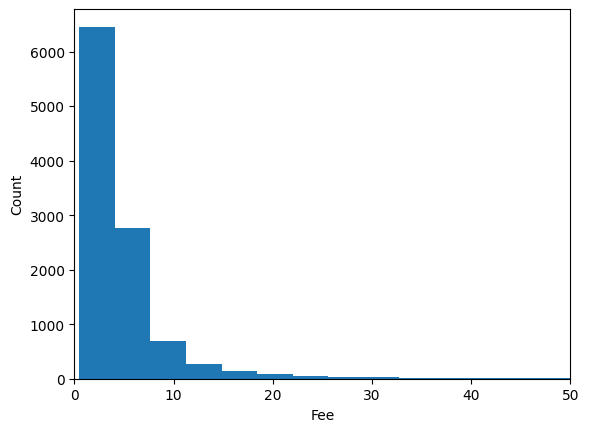

In [53]:
plt.hist(df['fee'], bins=50)
plt.xlim(0,50)
plt.xlabel('Fee')
plt.ylabel('Count')
plt.show()

The histogram shows that the transaction fee distribution is heavily right-skewed, with most transactions having low fees while a few extreme values create outliers at the high end.

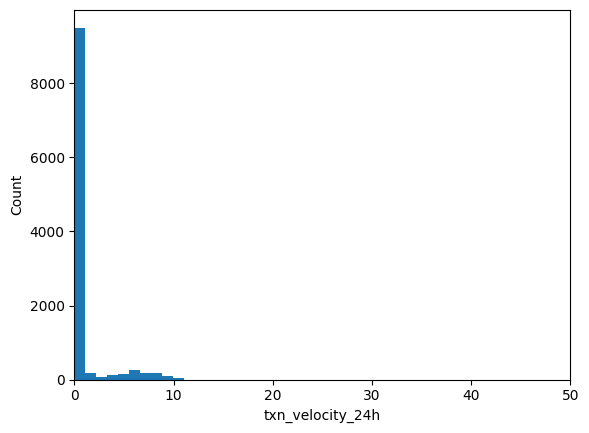

In [54]:
plt.hist(df['txn_velocity_24h'], bins=10)
plt.xlim(0,50)
plt.xlabel('txn_velocity_24h')
plt.ylabel('Count')
plt.show()

The histogram shows that most users perform very few transactions within 24 hours, while a small number of users exhibit unusually high transaction activity, indicating potential outliers or suspicious behavior.

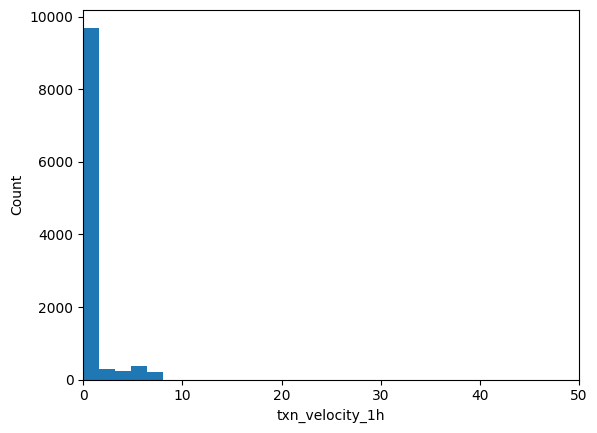

In [55]:
plt.hist(df['txn_velocity_1h'], bins=5)
plt.xlim(0,50)
plt.xlabel('txn_velocity_1h')
plt.ylabel('Count')
plt.show()

This also shows that most users perform very few transactions within an hour, while a small number of users exhibit unusually high transaction activity, indicating potential outliers or suspicious behavior.

BIVARIATE EDA

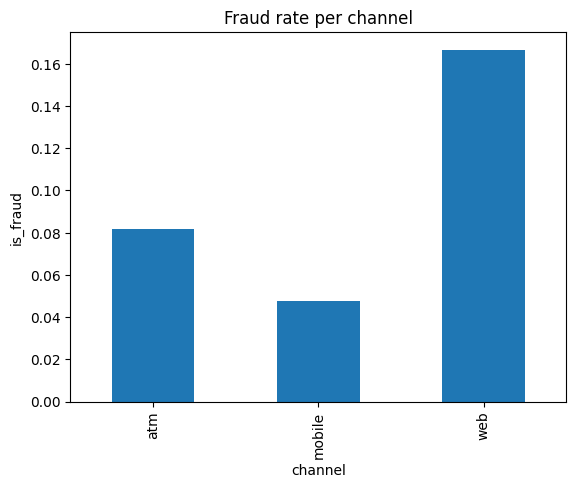

In [56]:
#the chart shows Fraud rate per channel
df.groupby('channel')['is_fraud'].mean().plot(kind='bar')
plt.xlabel('channel')
plt.ylabel('is_fraud')
plt.title('Fraud rate per channel')
plt.show()

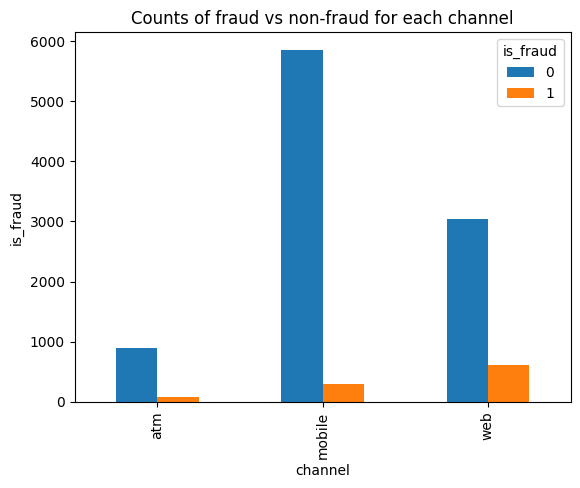

In [57]:
# The chart shows counts of fraud vs non-fraud for each channel.
df.groupby('channel')['is_fraud'].value_counts().unstack().plot(kind='bar', stacked=False)
plt.xlabel('channel')
plt.ylabel('is_fraud')
plt.title('Counts of fraud vs non-fraud for each channel')
plt.show()

The first chart shows fraud risk by measuring fraud rate, Transactions from the web channel have a higher fraud rate than mobile transactions, while the other shows fraud volume by measuring fraud counts by channel. Also transactions from the web channel have a higher fraud rate than mobile transactions.

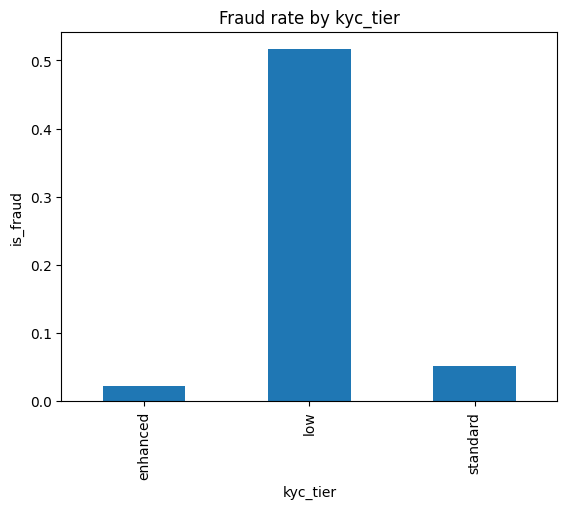

In [58]:
#the chart shows Fraud rate per kyc_tier
df.groupby('kyc_tier')['is_fraud'].mean().plot(kind='bar')
plt.xlabel('kyc_tier')
plt.ylabel('is_fraud')
plt.title('Fraud rate by kyc_tier')
plt.show()

The chart shows that fraud rates are significantly higher among users with low KYC verification, while users with enhanced verification exhibit the lowest fraud risk.

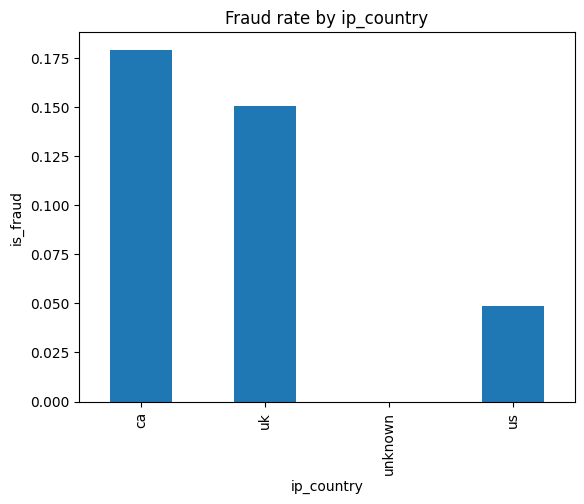

In [59]:
#the chart shows Fraud rate per ip_country
df.groupby('ip_country')['is_fraud'].mean().plot(kind='bar')
plt.xlabel('ip_country')
plt.ylabel('is_fraud')
plt.title('Fraud rate by ip_country')
plt.show()

ca (canada) has the highest rate of fraud transaction based on their ip.

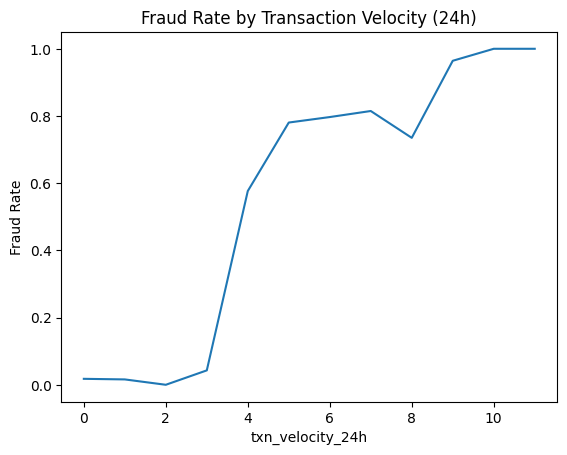

In [60]:
df.groupby('txn_velocity_24h')['is_fraud'].mean().plot()

plt.xlabel('txn_velocity_24h')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Transaction Velocity (24h)')

plt.show()

This chart reveals that Fraud increases with higher transaction velocity. Fraud spikes at specific velocity levels. This shows a strong correlation between how many transactions an account performs in a 24-hour period and the likelihood that those transactions are fraudulent.

For accounts making 0 to 3 transactions in a day, the fraud rate is nearly zero.
This represents typical, legitimate user behavior. The risk is extremely low in this range.

There is a massive jump starting at the 3rd transaction.
By the time an account reaches 5 transactions in 24 hours, the fraud rate climbs to roughly 75%. This suggests that "burst" activity is a major red flag for this specific dataset.

Between 5 and 8 transactions, the fraud rate stays relatively flat, hovering between 70% and 80%.
Interestingly, there is a slight "dip" around 8 transactions. This sometimes happens in data if there is a small cluster of very active legitimate users (power users), but the risk remains significantly higher than the baseline.

After 8 transactions, the curve spikes again, reaching nearly 1.0 (100%) by the 10th transaction. This clearly shows that any account performing 10 or more transactions in a single day is almost guaranteed to be fraudulent.



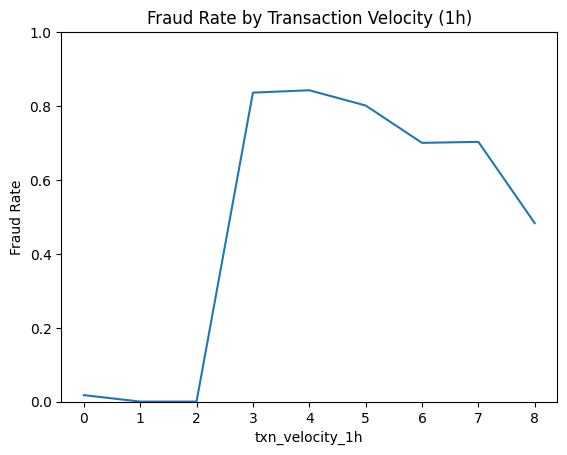

In [61]:
df.groupby('txn_velocity_1h')['is_fraud'].mean().plot()

plt.xlabel('txn_velocity_1h')
plt.ylabel('Fraud Rate')
plt.ylim(0,1)
plt.title('Fraud Rate by Transaction Velocity (1h)')

plt.show()

This chart, shows the relationship between how frequently a user makes transactions in one hour and the likelihood that those transactions are fraudulent.

When there are only 1 or 2 transactions per hour, the fraud rate is nearly zero. This represents "normal" or safe user behavior.
The Critical Jump: There is a massive spike between 2 and 3 transactions. Once a user hits that 3rd transaction within an hour, the probability of fraud jumps from near 0% to over 80%.

The fraud rate peaks and plateaus between 3 and 5 transactions per hour.
In this range, more than 70% to 80% of transactions are fraudulent. This suggests that "burst" activity—where many transactions happen in quick succession—is a primary indicator of a compromised account or a bot attack in your dataset.

After 5 transactions, the fraud rate begins to decline, dropping to about 45% by the 8th transaction.


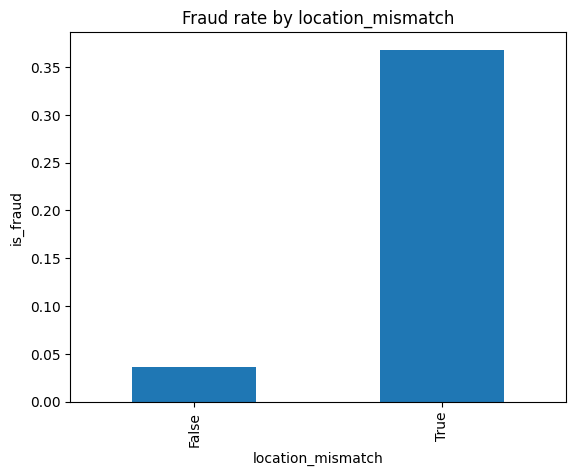

In [62]:
#the chart shows Fraud rate per location_mismatch
df.groupby('location_mismatch')['is_fraud'].mean().plot(kind='bar')
plt.xlabel('location_mismatch')
plt.ylabel('is_fraud')
plt.title('Fraud rate by location_mismatch')
plt.show()

This bar chart compares the likelihood of a transaction being fraudulent based on whether the transaction location matches the user's expected location.

location_mismatch = False: The transaction took place in a location consistent with the user's profile (e.g., their home city or a known frequent location).
location_mismatch = True: The transaction occurred in an unexpected or new location that doesn't align with the user's typical behavior.

When there is no location mismatch, the fraud rate is very low—appearing to be around 3–5% (0.03–0.05 on the y-axis). These are generally considered safe, routine transactions, whereas when a location mismatch is detected, the fraud rate spikes dramatically to over 35% (roughly 0.36).

A transaction with a location mismatch is roughly 7 to 9 times more likely to be fraudulent than one without a mismatch


From all of the above EDA charts, we can tell that variables like location_mismatch, channels, transaction_velocities, kyc_tier are very high-importance feature for our machine learning model.

FEATURE  ENGINEERING

In [63]:
df['timestamp'].unique()

<DatetimeArray>
['2022-10-03 18:40:59.468549+00:00', '2022-10-03 20:39:38.468549+00:00',
 '2022-10-03 23:02:43.468549+00:00', '2022-10-04 01:08:53.468549+00:00',
 '2022-10-04 09:35:03.468549+00:00', '2022-10-04 12:09:59.468549+00:00',
 '2022-10-04 12:37:41.468549+00:00', '2022-10-04 16:27:44.468549+00:00',
 '2022-10-04 21:00:36.468549+00:00', '2022-10-04 21:20:42.468549+00:00',
 ...
 '2025-11-24 13:42:17.573611+00:00', '2025-11-25 00:45:10.573611+00:00',
 '2025-11-25 07:44:29.573611+00:00', '2025-11-25 07:56:54.573611+00:00',
 '2025-11-25 09:48:28.573611+00:00', '2025-11-25 10:05:35.573611+00:00',
 '2025-11-26 07:09:56.573611+00:00', '2025-11-27 06:19:11.573611+00:00',
 '2025-11-28 00:53:28.573611+00:00', '2025-11-29 20:10:47.573611+00:00']
Length: 10590, dtype: datetime64[ns, UTC]

In [64]:
# Extracting time-based features from timestamp
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['month'] = df['timestamp'].dt.month

print(df[['hour','day_of_week','is_weekend','month']].head())


   hour  day_of_week  is_weekend  month
0    18            0           0     10
1    20            0           0     10
2    23            0           0     10
3     1            1           0     10
4     9            1           0     10


In [65]:
# checking the particular hour of the day with highest count
df['hour'].value_counts().reset_index()

,hour,count
0,4,503
1,19,491
2,3,480
3,23,477
4,8,471
5,5,471
6,15,467
7,18,467
8,6,464
9,16,461


In [66]:
# Fraud rate by hour
fraud_rate_by_hour = df.groupby('hour')['is_fraud'].mean().reset_index()
fraud_rate_by_hour

,hour,is_fraud
0,0,0.064159
1,1,0.065327
2,2,0.079903
3,3,0.122917
4,4,0.186879
5,5,0.163482
6,6,0.213362
7,7,0.186788
8,8,0.129512
9,9,0.047059


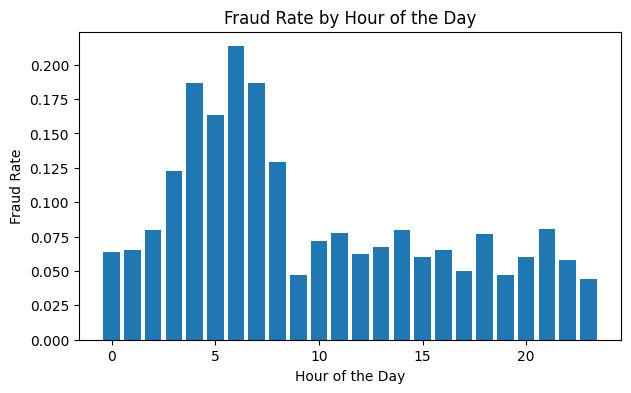

In [67]:
plt.figure(figsize=(7,4))

plt.bar(fraud_rate_by_hour.index, fraud_rate_by_hour['is_fraud'])

plt.xlabel('Hour of the Day')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour of the Day')

plt.show()

The derived hour column helped to discover that fraudulent transactions are high between the hours of 3am to 7am.

In [68]:
df['day_of_week'].value_counts().reset_index()

,day_of_week,count
0,4,1572
1,0,1569
2,3,1568
3,1,1557
4,2,1513
5,5,1512
6,6,1489


Day of the week was not used as a threshold-based feature because there was no specific day with a significantly higher transaction count compared to the others. The number of transactions appears to be relatively evenly distributed across all days of the week.

In [69]:
df['account_age_days'].unique()

array([ 263,  947,  367,  147,  257,  616, 1041, 1016, 1018,  298,  853,
        366,  172,    4,   63,  615,  830,  564,  415,  824,  272,  454,
        385,  661,  725,   34,  718,  805,  859,  684,  281,  954,  242,
        969,  716,  585,  648,  704,  214, 1035,  790,  985, 1048,  698,
       1011,  794,  638, 1088,  888, 1066,  566, 1027,  477,  992, 1089,
       1058,  132,  935,  259,  532,  652,  139,  113, 1092,  740,  819,
        449,  494,  903,  203,  213,  717,  882,  783,  657,  533,  393,
        962,  781,  225,  938,   86,  686,  446,  810,  714, 1074,  803,
        291,  916,  102,  587,  188,  236,   61,  987,  437,  589,  210,
         35,  293,  546,  707,  741,  458,  438,  347,  620,   24,   14,
         65,   29, 1095,  149,   15,   94,   10,  256,   91,  581,  287,
        765,    1,   98,   26,   25,   16,   59,    2,  168,   62,   43,
          3,   11,    7,  335,   17,   90,   80,   22,  520,   12,  118,
         53,  250,    9,   21,   23,   87,    6,  2

In [70]:
# Fraud rate by account age bucket
df['account_age_bucket'] = pd.cut(df['account_age_days'], bins=[0, 30, 90, 180, 365, 2000], labels=['<30', '30-90', '90-180', '180-365', '>365'])

fraud_rate_by_account_age = df.groupby('account_age_bucket')['is_fraud'].mean().reset_index()
fraud_rate_by_account_age

/tmp/ipykernel_6620/2781904611.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate_by_account_age = df.groupby('account_age_bucket')['is_fraud'].mean().reset_index()


,account_age_bucket,is_fraud
0,<30,0.368681
1,30-90,0.442584
2,90-180,0.023736
3,180-365,0.016901
4,>365,0.010534


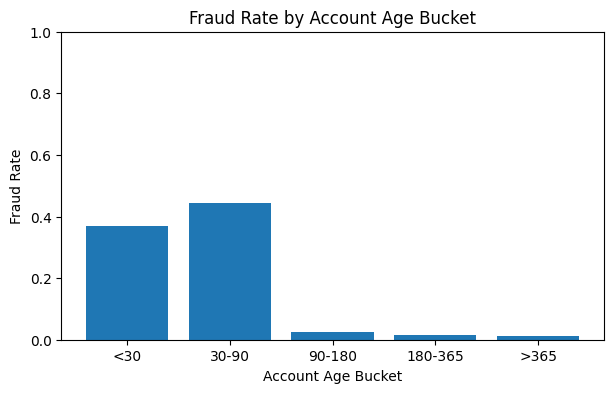

In [71]:
plt.figure(figsize=(7,4))
plt.bar(fraud_rate_by_account_age['account_age_bucket'], fraud_rate_by_account_age['is_fraud'])
plt.xlabel('Account Age Bucket')
plt.ylabel('Fraud Rate')
plt.ylim(0,1)
plt.title('Fraud Rate by Account Age Bucket')
plt.show()

In [72]:
df['device_trust_score'].unique()

array([0.522, 0.475, 0.939, 0.551, 0.894, 0.702, 0.625, 0.867, 0.944,
       0.934, 0.336, 0.401, 0.784, 0.68 , 0.186, 0.662, 0.881, 0.892,
       0.83 , 0.853, 0.515, 0.742, 0.799, 0.658, 0.744, 0.568, 0.607,
       0.792, 0.372, 0.71 , 0.75 , 0.92 , 0.824, 0.794, 0.427, 0.953,
       0.6  , 0.96 , 0.833, 0.704, 0.576, 0.333, 0.912, 0.883, 0.789,
       0.62 , 0.398, 0.596, 0.497, 0.43 , 0.718, 0.717, 0.803, 0.79 ,
       0.825, 0.365, 0.426, 0.731, 0.77 , 0.457, 0.277, 0.839, 0.866,
       0.904, 0.81 , 0.873, 0.901, 0.777, 0.864, 0.923, 0.349, 0.719,
       0.691, 0.842, 0.775, 0.779, 0.554, 0.552, 0.494, 0.454, 0.809,
       0.483, 0.624, 0.732, 0.862, 0.696, 0.672, 0.674, 0.886, 0.585,
       0.508, 0.774, 0.689, 0.631, 0.574, 0.678, 0.822, 0.544, 0.377,
       0.871, 0.841, 0.791, 0.787, 0.9  , 0.588, 0.642, 0.664, 0.56 ,
       0.882, 0.627, 0.716, 0.462, 0.971, 0.546, 0.655, 0.906, 0.683,
       0.232, 0.714, 0.654, 0.807, 0.94 , 0.806, 0.801, 0.85 , 0.773,
       0.496, 0.836,

In [73]:
# Fraud rate by device trust score bucket
df['device_trust_score_bucket'] = pd.cut(df['device_trust_score'], bins=[0, 0.3, 0.5, 0.7, 0.9], labels=['<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9, >0.9'])

fraud_rate_by_device_trust_score = df.groupby('device_trust_score_bucket')['is_fraud'].mean().reset_index()
fraud_rate_by_device_trust_score

/tmp/ipykernel_6620/3931724404.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate_by_device_trust_score = df.groupby('device_trust_score_bucket')['is_fraud'].mean().reset_index()


,device_trust_score_bucket,is_fraud
0,<0.3,0.846260
1,0.3-0.5,0.111424
2,0.5-0.7,0.020379
3,"0.7-0.9, >0.9",0.032597


/tmp/ipykernel_6620/3514211897.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate_by_device_trust_score = df.groupby('device_trust_score_bucket')['is_fraud'].mean().reset_index()


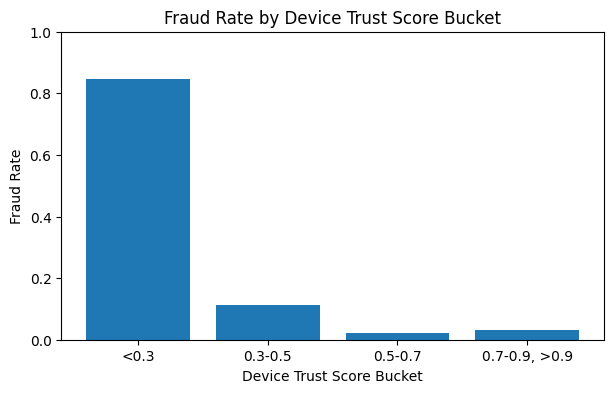

In [74]:
df['device_trust_score_bucket'] = pd.cut(df['device_trust_score'], bins=[0, 0.3, 0.5, 0.7, 0.9], labels=['<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9, >0.9'])

fraud_rate_by_device_trust_score = df.groupby('device_trust_score_bucket')['is_fraud'].mean().reset_index()

plt.figure(figsize=(7,4))
plt.bar(fraud_rate_by_device_trust_score['device_trust_score_bucket'], fraud_rate_by_device_trust_score['is_fraud'])
plt.xlabel('Device Trust Score Bucket')
plt.ylabel('Fraud Rate')
plt.ylim(0,1)
plt.title('Fraud Rate by Device Trust Score Bucket')
plt.show()

In [75]:
df['ip_risk_score'].unique()

array([0.123, 0.569, 0.437, 0.594, 0.121, 0.094, 0.299, 0.087, 0.182,
       0.413, 0.318, 0.254, 0.109, 0.151, 0.423, 0.329, 0.316, 0.24 ,
       0.448, 0.066, 0.366, 0.29 , 0.15 , 0.291, 0.163, 0.194, 0.424,
       0.554, 0.41 , 0.647, 0.27 , 0.271, 0.537, 0.223, 0.258, 0.064,
       0.931, 0.197, 0.483, 0.392, 0.368, 0.169, 0.378, 0.478, 0.336,
       0.199, 0.289, 0.42 , 0.228, 0.108, 0.583, 0.267, 0.468, 0.328,
       0.129, 0.504, 0.327, 0.31 , 0.395, 0.568, 0.973, 0.394, 0.2  ,
       0.235, 0.599, 0.341, 0.269, 0.137, 0.422, 0.416, 0.337, 0.236,
       0.417, 0.458, 0.148, 0.529, 0.147, 0.195, 0.205, 0.402, 0.516,
       0.255, 0.303, 0.669, 0.222, 0.359, 0.253, 0.159, 0.379, 0.94 ,
       0.518, 0.076, 0.062, 0.056, 0.204, 0.396, 0.361, 0.607, 0.219,
       0.538, 0.426, 0.279, 0.672, 0.295, 0.18 , 0.353, 0.321, 0.256,
       0.265, 0.116, 0.286, 0.512, 0.406, 0.142, 0.451, 0.677, 0.389,
       0.075, 0.08 , 0.67 , 0.288, 0.425, 0.277, 0.057, 0.171, 0.427,
       0.509, 0.029,

In [76]:
# Fraud rate by IP risk score buckets
df['ip_risk_score_bucket'] = pd.cut(df['ip_risk_score'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.8], labels=['<0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '>0.8'])

fraud_rate_by_ip_risk_score = df.groupby('ip_risk_score_bucket')['is_fraud'].mean().reset_index()
fraud_rate_by_ip_risk_score

/tmp/ipykernel_6620/3797634563.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate_by_ip_risk_score = df.groupby('ip_risk_score_bucket')['is_fraud'].mean().reset_index()


,ip_risk_score_bucket,is_fraud
0,<0.2,0.014792
1,0.2-0.4,0.019426
2,0.4-0.6,0.021103
3,0.6-0.8,0.084416
4,>0.8,0.625707


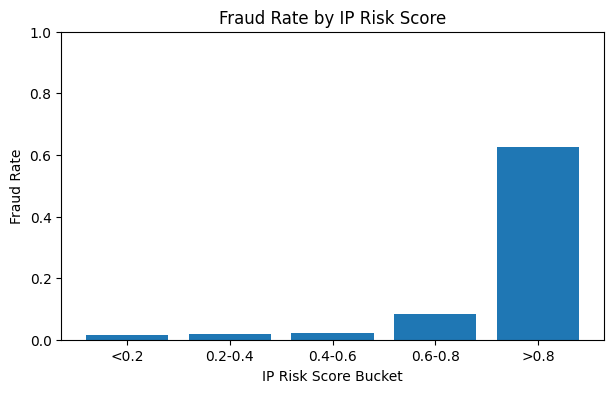

In [77]:
plt.figure(figsize=(7,4))
plt.bar(fraud_rate_by_ip_risk_score['ip_risk_score_bucket'], fraud_rate_by_ip_risk_score['is_fraud'])
plt.xlabel('IP Risk Score Bucket')
plt.ylabel('Fraud Rate')
plt.ylim(0,1)
plt.title('Fraud Rate by IP Risk Score')
plt.show()


In [78]:
df['amount_usd'].max()

12497.9

In [79]:
#Fraud rate by Amount(USD) bucket
df['amount_usd_bucket'] = pd.cut(df['amount_usd'], bins=[0, 250, 500, 1000, 5000, 10000, 20000], labels=['<$250', '$250-500', '$500-1k', '$1k-5k', '$5k-10k', '>$10k'])

fraud_rate_by_amount_usd = df.groupby('amount_usd_bucket')['is_fraud'].mean().reset_index()
fraud_rate_by_amount_usd


/tmp/ipykernel_6620/272434605.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate_by_amount_usd = df.groupby('amount_usd_bucket')['is_fraud'].mean().reset_index()


,amount_usd_bucket,is_fraud
0,<$250,0.029640
1,$250-500,0.112082
2,$500-1k,0.301768
3,$1k-5k,0.744318
4,$5k-10k,0.136842
5,>$10k,0.166667


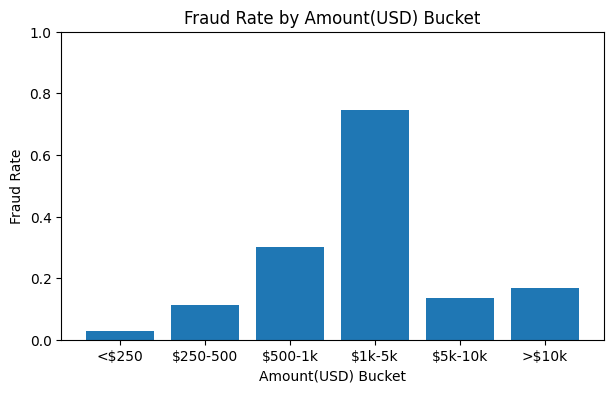

In [80]:
plt.figure(figsize=(7,4))
plt.bar(fraud_rate_by_amount_usd['amount_usd_bucket'], fraud_rate_by_amount_usd['is_fraud'])
plt.xlabel('Amount(USD) Bucket')
plt.ylabel('Fraud Rate')
plt.ylim(0,1)
plt.title('Fraud Rate by Amount(USD) Bucket')
plt.show()

In [81]:
# Creating a threshold based features from the following risk_signal
df['late_night_hours'] = ((df['hour'] >= 3) & (df['hour'] <= 7)).astype(int)
df['amount_high'] = (df['amount_usd'] >= 1000).astype(int)
df['high_ip_risk'] = (df['ip_risk_score'] > 0.8).astype(int)
df['low_device_trust'] = (df['device_trust_score'] < 0.5).astype(int)
df['new_account'] = ((df['account_age_days'] >= 30)&(df['account_age_days'] < 90)).astype(int)
df['very_new_account'] = (df['account_age_days'] < 30).astype(int)
df['velocity_spike'] = (df['txn_velocity_1h'] >= 3).astype(int)

high_risk_signal_features = df[['late_night_hours', 'amount_high', 'high_ip_risk', 'low_device_trust', 'new_account', 'velocity_spike']]
high_risk_signal_features.head()

,late_night_hours,amount_high,high_ip_risk,low_device_trust,new_account,velocity_spike
0,0,0,0,0,0,0
1,0,0,0,1,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


In [82]:
high_risk_signal_features.describe()

,late_night_hours,amount_high,high_ip_risk,low_device_trust,new_account,velocity_spike
count,10780.000000,10780.000000,10780.000000,10780.000000,10780.000000,10780.000000
mean,0.218646,0.053061,0.114750,0.231725,0.031262,0.098516
std,0.413347,0.224166,0.318734,0.421954,0.174032,0.298025
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Threshold-based features were created based on key behavioural and risk indicators identified during exploratory analysis. These include low KYC verification levels, location mismatches between the registered country and IP address, and high-risk transaction characteristics such as high transaction amounts, elevated IP risk scores, and low device trust scores. These features were identified as high-risk thresholds due to their significantly elevated fraud rates. These thresholds were converted into binary risk indicators to enhance the model's ability to detect suspicious transactions.

MODELLING

In [83]:
# Checking the features in our datasets
list(df.columns)

['transaction_id',
 'customer_id',
 'timestamp',
 'home_country',
 'source_currency',
 'dest_currency',
 'channel',
 'amount_src',
 'amount_usd',
 'fee',
 'exchange_rate_src_to_dest',
 'device_id',
 'new_device',
 'ip_address',
 'ip_country',
 'location_mismatch',
 'ip_risk_score',
 'kyc_tier',
 'account_age_days',
 'device_trust_score',
 'chargeback_history_count',
 'risk_score_internal',
 'txn_velocity_1h',
 'txn_velocity_24h',
 'corridor_risk',
 'is_fraud',
 'hour',
 'day_of_week',
 'is_weekend',
 'month',
 'account_age_bucket',
 'device_trust_score_bucket',
 'ip_risk_score_bucket',
 'amount_usd_bucket',
 'late_night_hours',
 'amount_high',
 'high_ip_risk',
 'low_device_trust',
 'new_account',
 'very_new_account',
 'velocity_spike']

In [84]:
# Dropping all temporary buckets column
df = df.drop(['account_age_bucket','device_trust_score_bucket','ip_risk_score_bucket','amount_usd_bucket'], axis=1)

In [85]:
# Also I will be dropping all identifiers column (Ids)
df = df.drop(['transaction_id', 'customer_id','device_id', 'ip_address'], axis=1)

In [86]:
df['is_fraud'].isna().sum()

np.int64(0)

In [87]:

df['is_fraud'].value_counts()

,count
is_fraud,
0,9799
1,981


In [88]:
# Dropping some irrelevant variables
df = df.drop(['chargeback_history_count', 'month', 'exchange_rate_src_to_dest'], axis=1)

In [89]:
df.shape

(10780, 30)

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10780 entries, 0 to 11399
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   timestamp            10780 non-null  datetime64[ns, UTC]
 1   home_country         10780 non-null  object             
 2   source_currency      10780 non-null  object             
 3   dest_currency        10780 non-null  object             
 4   channel              10780 non-null  object             
 5   amount_src           10780 non-null  float64            
 6   amount_usd           10780 non-null  float64            
 7   fee                  10780 non-null  float64            
 8   new_device           10780 non-null  bool               
 9   ip_country           10780 non-null  object             
 10  location_mismatch    10780 non-null  bool               
 11  ip_risk_score        10780 non-null  float64            
 12  kyc_tier             10

Feature Groups

In [91]:
#Defining categorical features
categorical_features = df.select_dtypes(include=['object','bool']).columns
categorical_features

Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'new_device', 'ip_country', 'location_mismatch', 'kyc_tier'],
      dtype='object')

In [92]:
#Defining numerical features
numerical_features = df.select_dtypes(include=['int','float']).columns.drop('is_fraud')
numerical_features

Index(['amount_src', 'amount_usd', 'fee', 'ip_risk_score', 'account_age_days',
       'device_trust_score', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'hour', 'day_of_week',
       'is_weekend', 'late_night_hours', 'amount_high', 'high_ip_risk',
       'low_device_trust', 'new_account', 'very_new_account',
       'velocity_spike'],
      dtype='object')

In [93]:
print(f"Categorical: {len(categorical_features)}")
print(f"Numerical: {len(numerical_features)}")
print(f"Dataset: {df.shape}")

Categorical: 8
Numerical: 20
Dataset: (10780, 30)


In [94]:
all_features = list(categorical_features) + list(numerical_features)
print(all_features)

['home_country', 'source_currency', 'dest_currency', 'channel', 'new_device', 'ip_country', 'location_mismatch', 'kyc_tier', 'amount_src', 'amount_usd', 'fee', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'hour', 'day_of_week', 'is_weekend', 'late_night_hours', 'amount_high', 'high_ip_risk', 'low_device_trust', 'new_account', 'very_new_account', 'velocity_spike']


Train_test Split


The data is split into: 80% of data used to train the model and 20% is reserved to test its performance on unseen data.

It is strongly recommended to sort the dataset chronologically before doing the train–test split. Since your dataset has a timestamp column, the order of events matters. This will prevent data leakage, help predict future transactions since model will trained on past transactions hence mimicing the real scenario.

Features like:txn_velocity_1h, txn_velocity_24h, new_device, account_age_days, new_account depend on historical order.
If data is not ordered by time, these features can become incorrect.



In [95]:
#sorting by timestamp
df = df.sort_values(by='timestamp')

# 80/20 train_test split
split_index = int(len(df) * 0.8) #This determines where the dataset should be split.
train_df = df.iloc[:split_index] #training on future transactions
test_df = df.iloc[split_index:] #testing on past transactions

#prepare X and y
X_train = train_df[all_features]
y_train = train_df['is_fraud']
X_test = test_df[all_features]
y_test = test_df['is_fraud']

print(f"\nX_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")


X_train: (8624, 28), y_train: (8624,)
X_test: (2156, 28), y_test: (2156,)


In [96]:
# Building preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

# Fit on train, transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Original features: {len(all_features)}")
print(f"Processed features: {X_train_processed.shape[1]}")

Original features: 28
Processed features: 42


Logistic Regression

In [97]:
# Training Logistic regression with a balanced class weight
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_processed, y_train)

# Predicting on test
y_pred_lr = lr_model.predict(X_test_processed)
y_proba_lr = lr_model.predict_proba(X_test_processed)[:, 1]

# Evaluation
print("Logistic Regression Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")

Logistic Regression Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.96      0.98      1848
       Fraud       0.80      0.95      0.87       308

    accuracy                           0.96      2156
   macro avg       0.89      0.95      0.92      2156
weighted avg       0.96      0.96      0.96      2156


Confusion Matrix:
[[1774   74]
 [  16  292]]

ROC_AUC Score: 0.9835


Random Forest

In [98]:
# Training Random forest with balanced class weight
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100, max_depth=10, n_jobs=-1)
rf_model.fit(X_train_processed, y_train)

# Predicting on test
y_pred_rf = rf_model.predict(X_test_processed)
y_proba_rf = rf_model.predict_proba(X_test_processed)[:, 1]

# Evaluation
print("Random Forest Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

Random Forest Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99      1848
       Fraud       1.00      0.92      0.96       308

    accuracy                           0.99      2156
   macro avg       0.99      0.96      0.98      2156
weighted avg       0.99      0.99      0.99      2156


Confusion Matrix:
[[1848    0]
 [  25  283]]

ROC_AUC Score: 0.9743


XGBoost

In [99]:
# Calculating scale pos weight for imbalance in xgboost classifier
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Training XGBoost model with balanced class weight
xgb_model = XGBClassifier(random_state=42, n_estimators = 100, max_depth = 6, learning_rate = 0.1, scale_pos_weight = scale_pos_weight, eval_metric='logloss')
xgb_model.fit(X_train_processed, y_train)


# Predicting on test
y_pred_xgb = xgb_model.predict(X_test_processed)
y_proba_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

# Evaluation
print("XGBoost Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

XGBoost Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.99      0.99      1848
       Fraud       0.93      0.92      0.93       308

    accuracy                           0.98      2156
   macro avg       0.96      0.95      0.96      2156
weighted avg       0.98      0.98      0.98      2156


Confusion Matrix:
[[1828   20]
 [  25  283]]

ROC_AUC Score: 0.9692


Gradient Boosting Model

In [100]:
# Training GradientBoosting model with balanced class weight
gb_model = GradientBoostingClassifier(random_state=42, n_estimators = 200,
learning_rate = 0.05, max_depth = 3, subsample = 0.8, min_samples_leaf = 50)
gb_model.fit(X_train_processed, y_train)

# Predicting on test
y_pred_gb = gb_model.predict(X_test_processed)
y_proba_gb = gb_model.predict_proba(X_test_processed)[:, 1]

# Evaluation
print("GradientBoosting Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_gb):.4f}")

GradientBoosting Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99      1848
       Fraud       1.00      0.92      0.96       308

    accuracy                           0.99      2156
   macro avg       0.99      0.96      0.98      2156
weighted avg       0.99      0.99      0.99      2156


Confusion Matrix:
[[1848    0]
 [  25  283]]

ROC_AUC Score: 0.9807


Fraud behaviour is non linear hence the reason tree models were used.

Logistic regression served as the baseline classifier model, while the tree-based ensemble models Random Forest captured nonlinear interactions between behavioural and risk signals such as transaction velocity, account age, and IP risk scores. Gradient boosting and XGBoost sequentially improved prediction performance by learning from previous model errors, enabling the detection of complex fraud patterns that simpler linear models could not capture.

From all four models trained, I will say Gradient Boosting performed the overall best and recommended for hyperparameter tuning. Considering: very high ROC-AUC, highest accuracy, strong fraud detection(perfect precision and strong recall), minimal false alarms(False Positive).

ADVANCED MODELING - Hyperparameter Tuning

Key Parameters to Tune:

- learning_rate: This controls how fast model learns

- n_estimators: This is the number of trees

- max_depth	: It has to do with the tree complexity

- min_samples_split: This is the minimum samples to split

- min_samples_leaf: This is the minimum samples per leaf

- subsample:	The fraction of data used per tree

For the purpose of the project, GridSearchCV will be used for Gradient Boosting due to its smaller and more manageable hyperparameter space, allowing the test of all combinations of parameters. In contrast, RandomizedSearchCV will be applied to XGBoost because of its larger and more complex parameter space, enabling efficient exploration of optimal parameter combinations.

In [101]:
# Hyperparameter tuning for gradient boosting model
gb = GradientBoostingClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_processed, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200, 'subsample': 0.8}
Best Score: 0.9387512896615927


In [102]:
# Evaluate tuned model on test set
y_pred_tuned = grid.predict(X_test_processed)
y_proba_tuned = grid.predict_proba(X_test_processed)[:, 1]

In [103]:
# Evaluation after hyperparameter tuning
print("Gradient Boosting Tuned Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

roc_auc_tuned = roc_auc_score(y_test, y_proba_tuned)
print(f"\nROC_AUC Score: {roc_auc_tuned:.4f}")

Gradient Boosting Tuned Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99      1848
       Fraud       0.99      0.92      0.95       308

    accuracy                           0.99      2156
   macro avg       0.99      0.96      0.97      2156
weighted avg       0.99      0.99      0.99      2156


Confusion Matrix:
[[1846    2]
 [  25  283]]

ROC_AUC Score: 0.9813


Hyperparameter tuning on the trained gradient boosting model resulted in a slight improvement in ROC-AUC score, indicating better model generalisation. While fraud recall remained unchanged, a slight increase in false positives was observed, reflecting a more balanced and less overfitted model. This highlights that further improvements in fraud detection would require enhanced feature engineering rather than additional parameter tuning.

In [104]:
# Hyperparameter tuning for XGBoost model

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'min_child_weight': [1, 3, 5],
    'scale_pos_weight': [scale_pos_weight]
}

xgb_tuned = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=25,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

xgb_tuned.fit(X_train_processed, y_train)

print("Best Params:", xgb_tuned.best_params_)
print("Best Score:", xgb_tuned.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Params: {'subsample': 0.7, 'scale_pos_weight': np.float64(11.814264487369986), 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 5, 'colsample_bytree': 0.7}
Best Score: 0.9386829690130325


In [105]:
#Evaluate tuned model on test set
y_pred_tuned = xgb_tuned.predict(X_test_processed)
y_proba_tuned = xgb_tuned.predict_proba(X_test_processed)[:, 1]

In [106]:
# Evaluation after hyperparameter tuning
print("XGBoost Tuned Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

roc_auc_tuned = roc_auc_score(y_test, y_proba_tuned)
print(f"\nROC_AUC Score: {roc_auc_tuned:.4f}")

XGBoost Tuned Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.98      0.99      1848
       Fraud       0.90      0.94      0.92       308

    accuracy                           0.98      2156
   macro avg       0.94      0.96      0.95      2156
weighted avg       0.98      0.98      0.98      2156


Confusion Matrix:
[[1816   32]
 [  19  289]]

ROC_AUC Score: 0.9813


Hyperparameter tuning for XGBoost model significantly improved the XGBoost model’s ROC-AUC score from 0.969 to 0.981, indicating enhanced discrimination between fraudulent and genuine transactions. The tuned model increased fraud recall from 0.92 to 0.94, reducing missed fraud cases, although this came with a slight increase in false positives. This trade-off reflects a more effective fraud detection strategy, prioritising the identification of fraudulent transactions over minimising false alerts.

APPLYING SMOTE TO GRADIENT BOOSTING MODEL

SMOTE is a technique used in machine learning to handle imbalanced datasets by creating synthetic (artificial) examples of the minority class.

In this fraud project:

Majority class = Genuine transactions

Minority class = Fraud transactions

SMOTE helps by increasing the number of fraud cases so the model can learn better.

The Core Idea Behind SMOTE

Instead of simply copying existing fraud cases (which can cause overfitting), SMOTE: Generates new, realistic fraud samples

How It Works:

- Pick a fraud data point

- Find its nearest fraud neighbours

- Create a new point between them

In [107]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train_processed, y_train)
print(y_train.value_counts())
print(y_train_sm.value_counts())

is_fraud
0    7951
1     673
Name: count, dtype: int64
is_fraud
0    7951
1    7951
Name: count, dtype: int64


In [108]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_train_sm, y_train_sm)

y_pred = gb_model.predict(X_test_processed)
y_prob = gb_model.predict_proba(X_test_processed)[:, 1]

# Evaluation
print("GradientBoosting Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

GradientBoosting Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99      1848
       Fraud       0.99      0.92      0.95       308

    accuracy                           0.99      2156
   macro avg       0.99      0.96      0.97      2156
weighted avg       0.99      0.99      0.99      2156


Confusion Matrix:
[[1845    3]
 [  24  284]]

ROC_AUC Score: 0.9821


I applied SMOTE to the gradient boosting model to see if there will be increase in the recall. The application of SMOTE resulted in a marginal improvement in ROC-AUC score and a slight reduction in missed fraud cases. However, the overall impact on recall was minimal, while introducing a small number of false positives. Smote was applied to see if it will increase the recall value. Since the model was already strong applying Smote was not necessary.

SHAP ANALYSIS

SHAP is a technique used to explain machine learning predictions — especially complex models like tree ensembles — in a way that shows how each feature contributes to a decision.

SHAP answers this question: “Why did the model say this transaction is fraud?”

It does this by assigning each feature a contribution value (positive or negative) to the prediction. SHAP is used to interpret model predictions by quantifying the contribution of each feature to fraud risk. This enables transparency in decision-making, helped identify key fraud drivers such as transaction velocity and IP risk score, and provided actionable insights for fraud analysts and business stakeholders.

SHAP is based on Game Theory, specifically Shapley values. It fairly distributes the “credit” of a prediction across features.


In [115]:
# Create the SHAP Explainer
#For tree-based models (Random Forest, Gradient Boosting, XGBoost), use TreeExplainer.
explainer = shap.TreeExplainer(gb_model)
shap_values_gb = explainer.shap_values(X_test_processed)
print(shap_values_gb.shape)



(2156, 42)


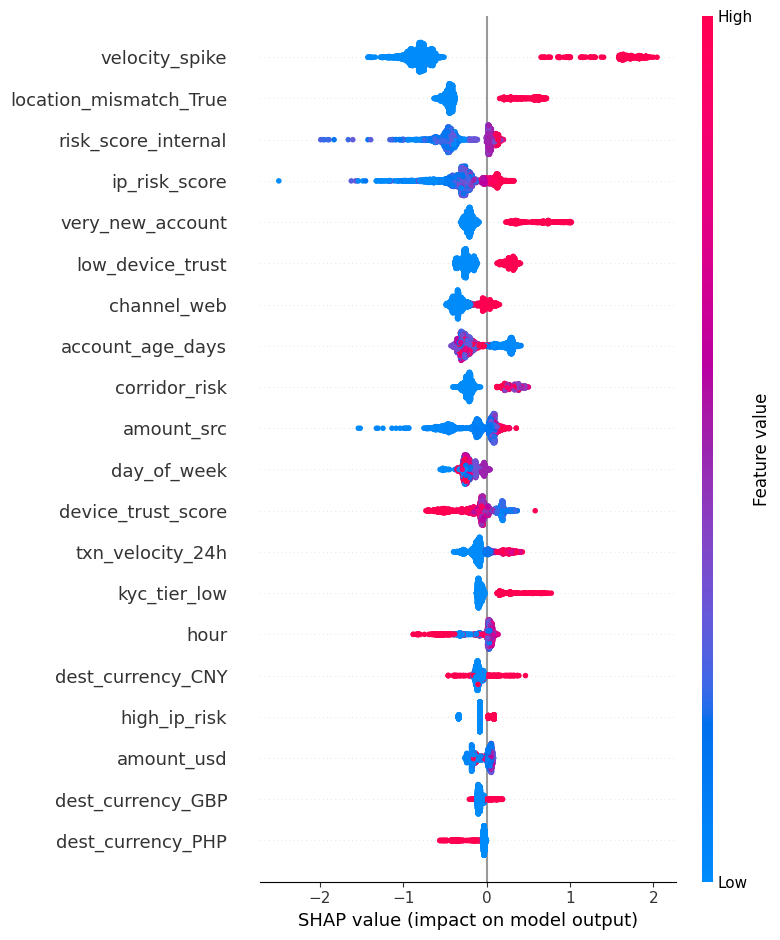

In [116]:
# Creating a clean feature name for the shap plot
feature_names = preprocessor.get_feature_names_out()
clean_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=clean_names
)
# beeswarm plot
shap.summary_plot(shap_values_gb, X_test_processed_df)

plt.show()

This is a SHAP beeswarm plot, and it shows which features matter most and how they influence fraud predictions. The Y-axis shows the  features (ranked by importance) while the X-axis shows the SHAP value (impact on prediction).
The Blue color represents Low feature value while the red color represents High feature value.

The Left part of the plot (negative SHAP value) pushes prediction toward Genuine while the Right part (positive SHAP value) pushes prediction toward Fraud.

The SHAP beeswarm plot highlights that transaction velocity spikes, location mismatch, internal risk scores, and IP risk scores are the most influential drivers of fraud predictions. High values of these features consistently push predictions toward fraud, while low values indicate genuine behaviour. The model captures a combination of behavioural anomalies, identity inconsistencies, and account risk factors, aligning closely with real-world fraud detection patterns.


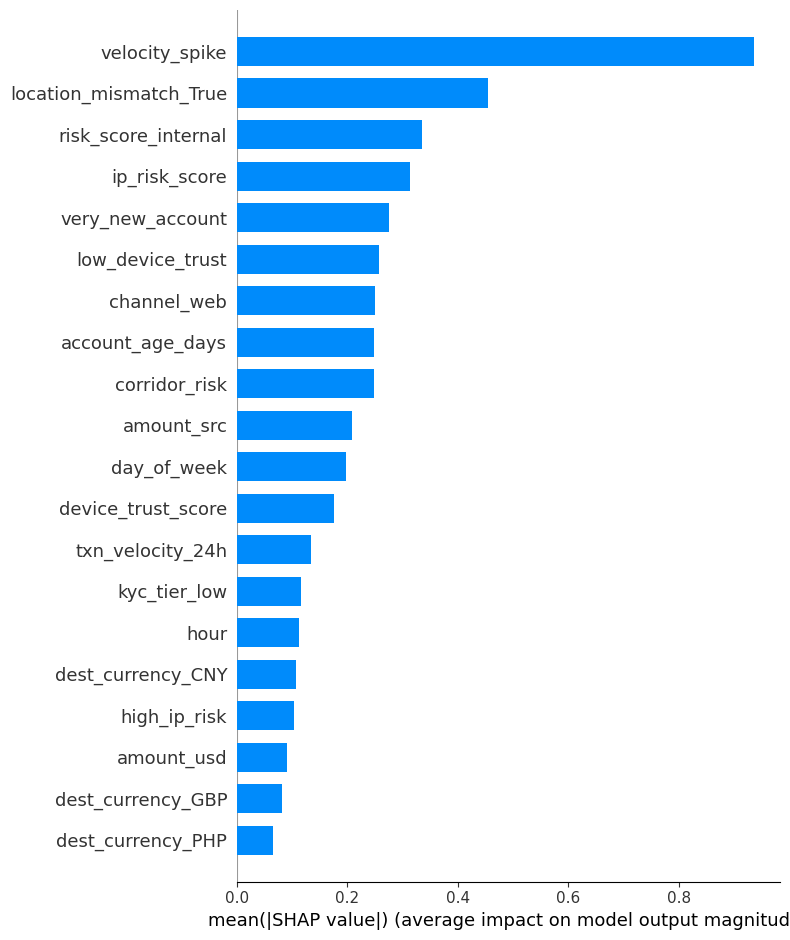

In [111]:
#Summary bar plot
shap.summary_plot(shap_values_gb, X_test_processed_df, plot_type="bar")
plt.show()

This is a SHAP summary bar plot, and it gives you a global ranking of feature importance based on how much each feature influences your model’s predictions. The Y-axis shows Features (ranked from most important to least important) while the X-axis shows Mean absolute SHAP value. Higher value shows feature has stronger impact on predictions.

Mean(|SHAP value|) measures how much a feature moves predictions (on average). The SHAP summary bar plot or feature importance analysis shows that transaction velocity spikes and location mismatches are the most influential drivers of fraud predictions. This indicates that the model primarily detects fraud through abnormal behavioural patterns and geographic inconsistencies, supported by additional risk signals such as IP risk and account trust features.

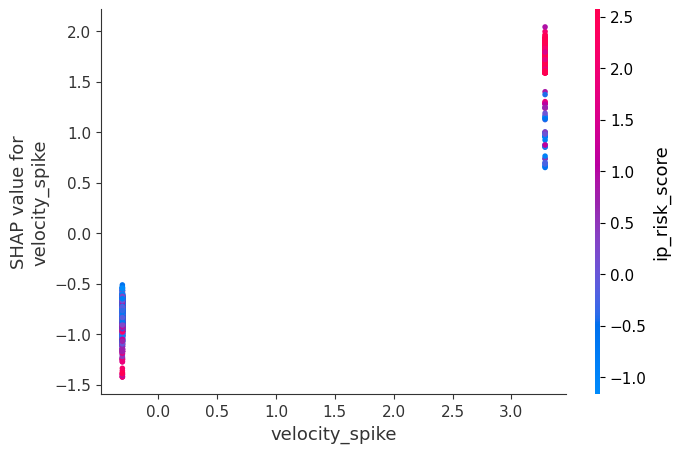

In [117]:
# SHAP dependence chart
shap.dependence_plot("velocity_spike", shap_values_gb, X_test_processed_df)
plt.show()

The above SHAP dependence plot helps you understand how a single feature e.g velocity_spike affects the model’s prediction across different values of that feature. The dependence plot shows: X-axis: feature value (velocity_spike), Y-axis: SHAP value for the feature, velocity_spike (impact on prediction).

The second feature shown in the colour legend represents feature interaction which is ip_risk_score (interaction feature). SHAP automatically selects the feature that interacts most strongly with the main feature.

The impact of velocity_spike on fraud prediction changes depending on the high_ip_risk score as shown in the plot above.

SHAP analysis was used to interpret the Gradient Boosting model and identify the most influential features driving fraud predictions. The SHAP summary plot revealed that location_mismatch, IP risk score, transaction velocity, and device trust score were the most important predictors. True Location mismatch and higher IP risk scores are red flags and significantly increased the probability of a transaction being classified as fraudulent.

Feature Importance

Converting SHAP Values to Feature Importance

In [113]:
# Calculate mean absolute SHAP value for each feature
importance = np.abs(shap_values_gb).mean(axis=0)

# Create dataframe
feature_importance = pd.DataFrame({"feature": X_test_processed_df.columns,"importance": importance})

# Sort features by importance
feature_importance = feature_importance.sort_values(by="importance", ascending=False
                                                    )
# show top fraud drivers
top_features = feature_importance.head(10)

print(top_features)

                   feature  importance
19          velocity_spike    0.935987
39  location_mismatch_True    0.454975
6      risk_score_internal    0.335232
3            ip_risk_score    0.312677
18        very_new_account    0.275891
16        low_device_trust    0.256458
34             channel_web    0.249935
4         account_age_days    0.248711
9            corridor_risk    0.247175
0               amount_src    0.208405


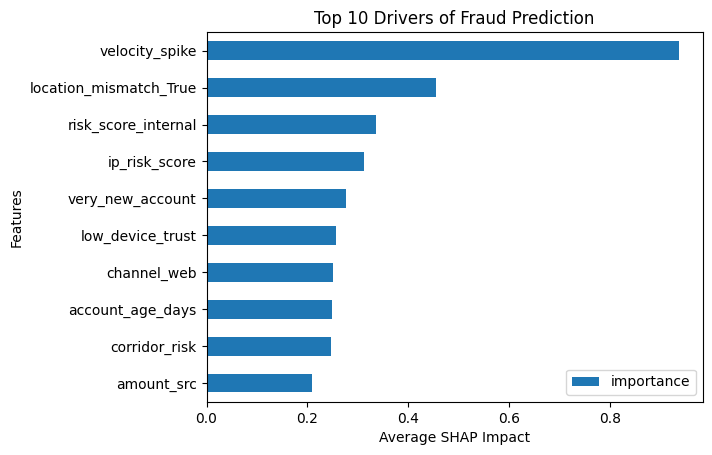

In [118]:
# Plotting the fraud drivers chart
top_features.plot.barh(x="feature", y="importance")

plt.title("Top 10 Drivers of Fraud Prediction")
plt.xlabel("Average SHAP Impact")
plt.ylabel("Features")
plt.gca().invert_yaxis()

plt.show()

Model Explainability

To ensure transparency and build stakeholder trust, the model’s predictions were interpreted using SHAP, a game-theoretic approach that explains how each feature contributes to individual and overall predictions.

SHAP provides both global explanations (which features matter most) and local explanations (how features influence a specific prediction), making it highly suitable for fraud detection use cases where interpretability is critical.

- Global Feature Importance

The SHAP summary analysis as shoen in the SHAP summary plot identified the most influential drivers of fraud predictions. The top features include:

1. Transaction velocity (velocity_spike)
2. Location mismatch (location_mismatch_True)
3. Internal risk score (risk_score_internal)
4. IP risk score (ip_risk_score)
5. Account age and trust indicators (very_new_account, device_trust_score)

Among these, transaction velocity spike emerged as the most dominant feature, indicating that sudden increases in transaction activity are the strongest signal of fraudulent behaviour. The Top Fraud Drivers interpretation:

1. Transaction Velocity (velocity_spike): The number of transactions performed by the same user/account within the last 24 hours or within 1 hour. High transaction velocity leads to Higher fraud risk. Fraudsters often attempt multiple transactions quickly before the account is blocked. A higher velocity_spike suggests unusually frequent transactions within a short time window, which is commonly associated with fraud patterns such as rapid account takeover or card testing.

2. Mismatch Location (true_mismatch_location): True location mismatch refers to situations where a user’s actual location (e.g., IP address, device location) does not match their expected or registered location (e.g., account country, usual login region). In genuine transactions, Users typically transact from consistent or predictable locations while in fraudulent transaction, Transactions often originate from unfamiliar or geographically inconsistent locations. Transactions flagged with a true location mismatch indicate activity occurring from a location inconsistent with the user’s historical or registered location. This is a strong indicator of potential fraud, particularly in cases of account takeover or unauthorized access. The model assigns higher fraud risk to such transactions, especially when combined with other risk signals like high transaction velocity or elevated IP risk.

3. Internal Risk Score (risk_score_internal): An internal fraud score can be generated from multiple signals such as: device fingerprint, behavioural patterns, transaction anomalies, user history etc. Higher scores indicate stronger evidence of anomalous or high-risk activity and significantly increase the likelihood of fraud classification.

4. IP Risk Score (ip_risk_score): A risk score assigned to the IP address based on historical fraud intelligence. The score usually considers: proxy usage, VPN, blacklisted IP, past fraud activity. Higher score lead Higher fraud probability. Transactions originating from IP addresses with higher ip_risk_score values are more likely to be fraudulent because these IPs are frequently linked to previously detected fraud activity.

Fraudulent transactions tend to occur when a transaction is done in an unfamiliar location(location_mismatch), originate from high-risk IP addresses, and exhibit unusually high transaction velocity within a short period. These behaviours significantly increase the model’s predicted fraud probability.

- Feature Interactions

SHAP dependence analysis shown in the SHAP dependence plot revealed strong interactions between features, particularly:

Velocity spike + IP risk score
Location mismatch + transaction velocity

These interactions show that fraud risk is not driven by a single factor but by a combination of behavioural anomalies and identity inconsistencies. For example, a high transaction velocity combined with a high-risk IP address significantly amplifies fraud probability.

- Behavioural vs Static Features

The model primarily relies on behavioural features rather than static attributes:

Behavioural: transaction velocity, activity spikes
Identity: IP risk, location mismatch
Account-based: account age, KYC tier

This demonstrates that the model captures dynamic user behaviour, which is more effective for detecting evolving fraud patterns.

- Model Transparency and Trust

The use of SHAP ensures that:

1. Predictions are interpretable and explainable
2. Key fraud drivers are aligned with real-world patterns
3. Stakeholders can understand and validate model decisions

- Why SHAP Matters to Stakeholders? Different stakeholders care about different things.

1. Fraud Analysts: They want to know why a transaction is flagged?

SHAP provides: Clear reasons (e.g., high velocity + risky IP) and helps validate alerts.

2. Business / Management: They want to know what drives fraud in the system?

SHAP shows: Key fraud drivers, risk patterns across customers and where to focus controls. for example, High velocity + true location mismatch = high fraud risk.

3. Compliance & Regulators: Very important in finance.

They require:Model transparency, Explainability and Fairness.

4. Data Scientists

SHAP helps you: Debug the model, Detect leakage, validate feature importance, understand non-linear behaviour.

- The Business Interpretation:

High transaction velocity leads to suspicious behaviour.

Risky IP leads to potential fraud location.

True location_mismatch leads to higher fraud risk.

Internal risk score leads to strong predictive signal.

- The feature that mostly lead to false positive:

SHAP analysis indicates that transaction velocity spike is the primary driver of false positives because It is the most dominant feature i.e it has the highest SHAP importance and Strongly pushes predictions toward fraud when high. Also it captures behaviour, not intent i.e High transaction velocity can occur in legitimate scenarios, for example; Salary payments, Bulk transfers, Business transactions, Promotions or peak usage periods. High transaction activity can occur in both fraudulent and legitimate scenarios.

Additional contributors include location mismatch and elevated IP risk scores, which may reflect genuine user behaviour such as travel or use of shared networks. These features capture behavioural anomalies rather than confirmed fraud, leading to occasional misclassification of legitimate transactions.

- Summary:

The explainability analysis confirms that the model detects fraud by identifying abnormal transaction behaviour, geographic inconsistencies, and low-trust account signals. These insights align closely with real-world fraud patterns, reinforcing confidence in the model’s reliability and practical applicability.